# Company-Level Hiring Score EDA
### Lloyds BCB — Hiring Dimension

分析 `company_hiring_score` 在 100k 公司样本中的分布、结构和信号质量。

**输入**
- `company_hiring_score.csv`：已合并 hiring score 的公司表（100k）


## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"

HIRING_CSV = Path("../output/hiring_100k.csv")   
OUTPUT_DIR = Path("./eda_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load Data

In [2]:
df = pd.read_csv(HIRING_CSV, low_memory=False)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Shape: (100000, 15)
Columns: ['CompanyNumber', 'CompanyName', 'primary_sector', 'CompanyStatus', 'company_age_years', 'Accounts_AccountCategory', 'sector_hiring_score', 'status_factor', 'age_factor', 'scale_factor', 'filing_freshness_factor', 'financing_factor', 'adjustment_factor', 'company_hiring_score', 'hiring_signal_quality']


,CompanyNumber,CompanyName,primary_sector,CompanyStatus,company_age_years,Accounts_AccountCategory,sector_hiring_score,status_factor,age_factor,scale_factor,filing_freshness_factor,financing_factor,adjustment_factor,company_hiring_score,hiring_signal_quality
0,13209628,TICKETY BOO TEETH LIMITED,Healthcare,Active,5.3,UNAUDITED ABRIDGED,52.9,1.0,1.15,0.95,0.85,1.0,0.928625,49.1,79.8
1,13887674,TECH INFUSION LIMITED,Fast growth & emerging sector,Active,4.4,TOTAL EXEMPTION FULL,72.5,1.0,1.15,0.90,0.85,1.0,0.879750,63.8,86.5
2,13408899,THE SCC ACADEMY LIMITED,Fast growth & emerging sector,Active,5.1,TOTAL EXEMPTION FULL,72.5,1.0,1.15,0.90,0.85,1.0,0.879750,63.8,86.5


In [3]:
# missing
print("=== Missing ===")
key_cols = [
    "company_hiring_score", "sector_hiring_score",
    "hiring_signal_quality", "adjustment_factor",
    "status_factor", "age_factor", "scale_factor",
    "filing_freshness_factor", "financing_factor",
]
for c in key_cols:
    if c in df.columns:
        n = df[c].isna().sum()
        print(f"  {c:<35} {n:>6} ({n/len(df)*100:.1f}%)")

=== Missing ===
  company_hiring_score                     0 (0.0%)
  sector_hiring_score                      0 (0.0%)
  hiring_signal_quality                    0 (0.0%)
  adjustment_factor                        0 (0.0%)
  status_factor                            0 (0.0%)
  age_factor                               0 (0.0%)
  scale_factor                             0 (0.0%)
  filing_freshness_factor                  0 (0.0%)
  financing_factor                         0 (0.0%)


## 2. company_hiring_score 分布

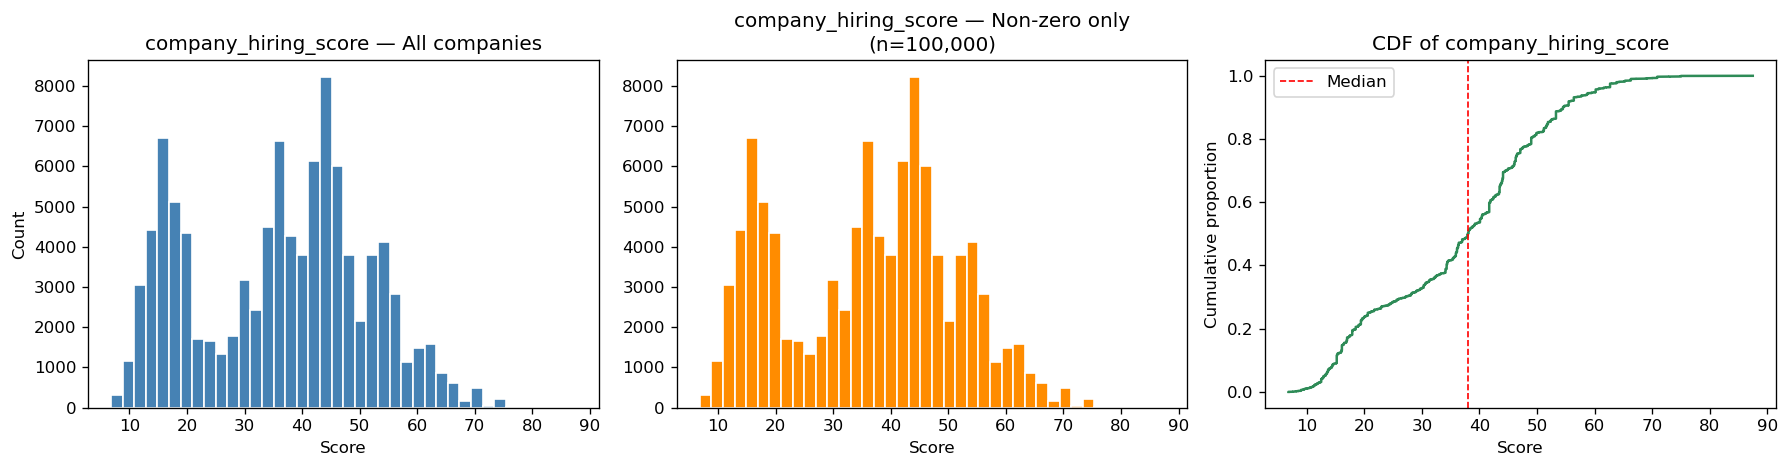

Descriptive stats:
count    100000.00
mean         36.18
std          14.99
min           6.80
25%          20.60
50%          38.00
75%          46.50
max          87.50

Zero score companies: 0 (0.0%)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ① 全体分布（含0分）
axes[0].hist(df["company_hiring_score"].fillna(0), bins=40,
             color="steelblue", edgecolor="white")
axes[0].set_title("company_hiring_score — All companies")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Count")

# ② 非零公司分布
nonzero = df[df["company_hiring_score"] > 0]["company_hiring_score"]
axes[1].hist(nonzero, bins=40, color="darkorange", edgecolor="white")
axes[1].set_title(f"company_hiring_score — Non-zero only\n(n={len(nonzero):,})")
axes[1].set_xlabel("Score")

# ③ 累积分布（CDF）
sorted_scores = np.sort(df["company_hiring_score"].fillna(0))
cdf = np.arange(1, len(sorted_scores)+1) / len(sorted_scores)
axes[2].plot(sorted_scores, cdf, color="seagreen", linewidth=1.5)
axes[2].axvline(sorted_scores[int(0.5*len(sorted_scores))],
                color="red", linestyle="--", linewidth=1, label="Median")
axes[2].set_title("CDF of company_hiring_score")
axes[2].set_xlabel("Score")
axes[2].set_ylabel("Cumulative proportion")
axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_score_distribution.png", bbox_inches="tight")
plt.show()

print("Descriptive stats:")
print(df["company_hiring_score"].describe().round(2).to_string())
print(f"\nZero score companies: {(df['company_hiring_score']==0).sum():,} "
      f"({(df['company_hiring_score']==0).mean()*100:.1f}%)")

## 3. 按行业分布

/var/folders/bs/fv2zw8q92b53tbz4z0w21h700000gn/T/ipykernel_36946/3824016896.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_sector, labels=[s[:20] for s in sector_order],


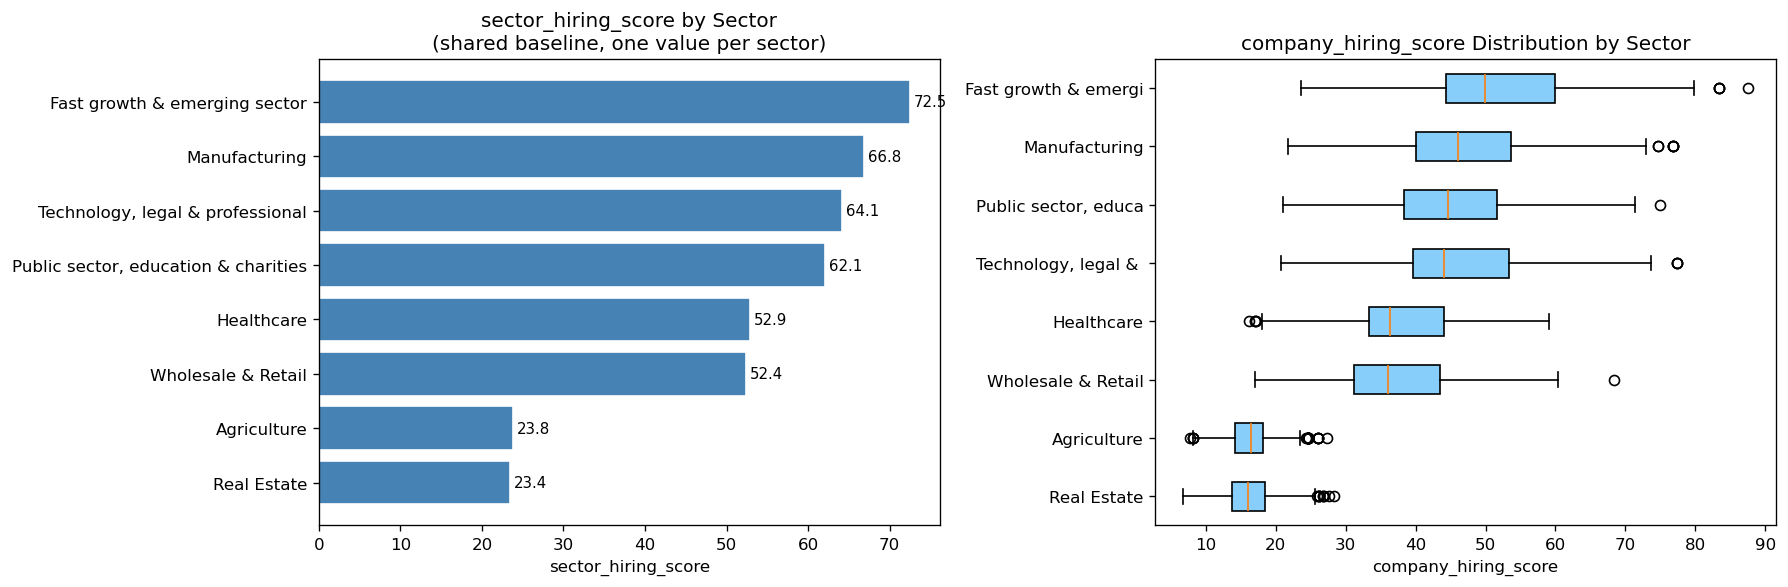

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ① 各行业 sector_hiring_score（行业基准分，每行业只有一个值）
if "sector_hiring_score" in df.columns:
    sector_scores = (df.groupby("primary_sector")["sector_hiring_score"]
                       .first().sort_values(ascending=True))
    axes[0].barh(sector_scores.index, sector_scores.values,
                 color="steelblue", edgecolor="white")
    axes[0].set_title("sector_hiring_score by Sector\n(shared baseline, one value per sector)")
    axes[0].set_xlabel("sector_hiring_score")
    for i, (v, l) in enumerate(zip(sector_scores.values, sector_scores.index)):
        axes[0].text(v + 0.5, i, f"{v:.1f}", va="center", fontsize=9)

# ② 各行业 company_hiring_score 箱线图
sector_order = (df.groupby("primary_sector")["company_hiring_score"]
                  .median().sort_values(ascending=True).index.tolist())
data_by_sector = [df[df["primary_sector"]==s]["company_hiring_score"].dropna().values
                  for s in sector_order]
bp = axes[1].boxplot(data_by_sector, labels=[s[:20] for s in sector_order],
                     patch_artist=True, vert=False)
for patch in bp["boxes"]:
    patch.set_facecolor("lightskyblue")
axes[1].set_title("company_hiring_score Distribution by Sector")
axes[1].set_xlabel("company_hiring_score")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_by_sector.png", bbox_inches="tight")
plt.show()

In [6]:
# 各行业统计汇总表
sector_summary = df.groupby("primary_sector").agg(
    n_companies        = ("CompanyNumber",          "count"),
    sector_score       = ("sector_hiring_score",     "first"),
    company_score_mean = ("company_hiring_score",    "mean"),
    company_score_med  = ("company_hiring_score",    "median"),
    company_score_std  = ("company_hiring_score",    "std"),
    zero_pct           = ("company_hiring_score",
                          lambda x: (x == 0).mean() * 100),
).round(2).sort_values("sector_score", ascending=False)

print("Sector summary:")
print(sector_summary.to_string())

Sector summary:
                                      n_companies  sector_score  company_score_mean  company_score_med  company_score_std  zero_pct
primary_sector                                                                                                                     
Fast growth & emerging sector                9761          72.5               51.08               49.9              10.43       0.0
Manufacturing                                7066          66.8               46.57               46.0               9.44       0.0
Technology, legal & professional            26432          64.1               45.43               44.1               9.23       0.0
Public sector, education & charities         4697          62.1               44.93               44.7               9.54       0.0
Healthcare                                   7913          52.9               37.95               36.4               7.81       0.0
Wholesale & Retail                          17841          5

## 4. 五因子分析

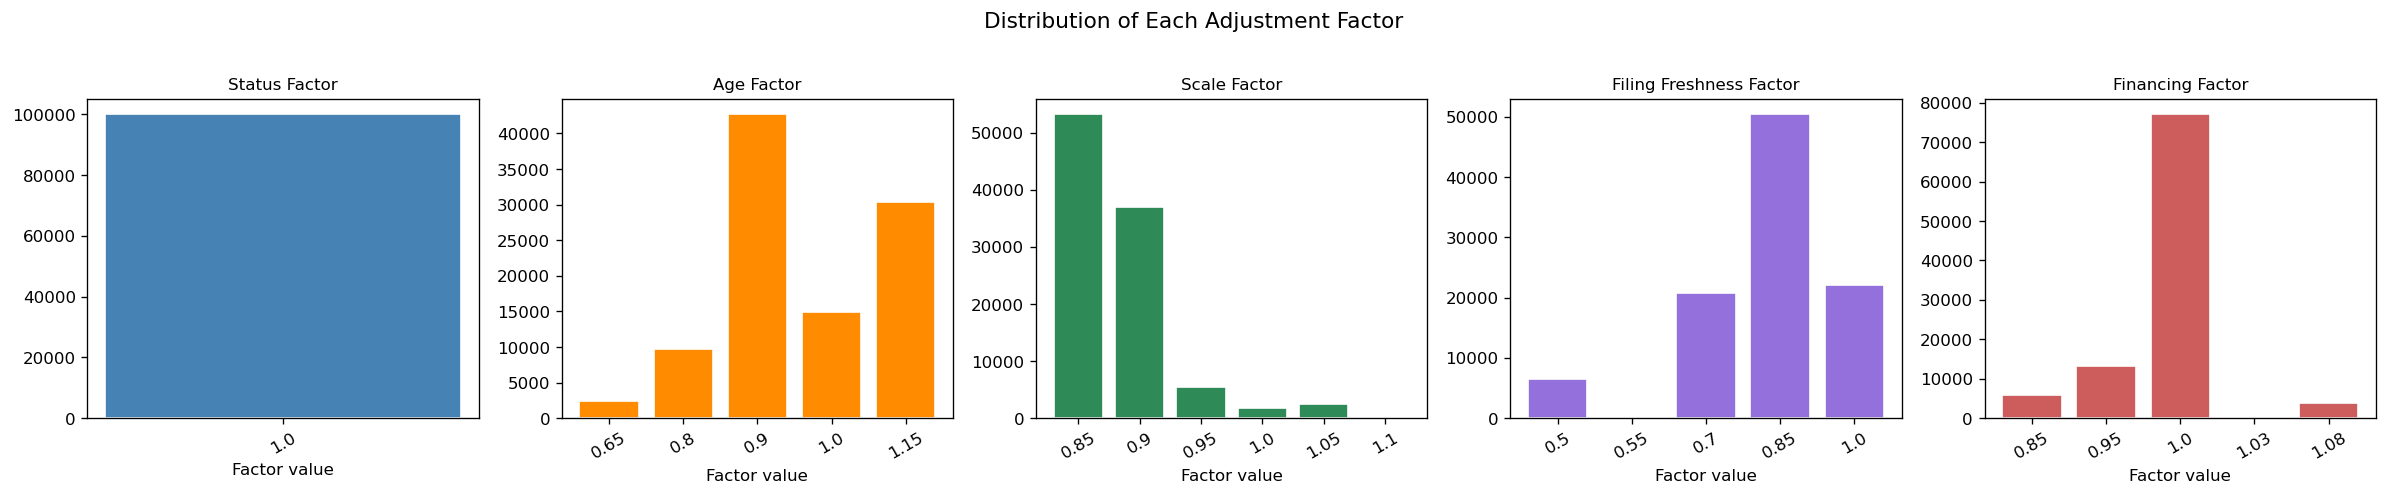

Factor means (active companies only):
  age_factor                          0.9749  ↓ discount
  scale_factor                        0.8819  ↓ discount
  filing_freshness_factor             0.8288  ↓ discount
  financing_factor                    0.9876  ↓ discount


In [7]:
factor_cols = [
    "status_factor", "age_factor", "scale_factor",
    "filing_freshness_factor", "financing_factor",
]
factor_cols = [c for c in factor_cols if c in df.columns]

fig, axes = plt.subplots(1, len(factor_cols), figsize=(4*len(factor_cols), 4))
if len(factor_cols) == 1:
    axes = [axes]

colors = ["steelblue", "darkorange", "seagreen", "mediumpurple", "indianred"]
for ax, col, color in zip(axes, factor_cols, colors):
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color=color, edgecolor="white")
    ax.set_title(col.replace("_", " ").title(), fontsize=10)
    ax.set_xlabel("Factor value")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Distribution of Each Adjustment Factor", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_adjustment_factors.png", bbox_inches="tight")
plt.show()

print("Factor means (active companies only):")
active = df[df["status_factor"] == 1.0] if "status_factor" in df.columns else df
for col in factor_cols[1:]:   # skip status (always 1 in active subset)
    if col in active.columns:
        m = active[col].mean()
        direction = "↑ uplift" if m > 1 else "↓ discount" if m < 1 else "→ neutral"
        print(f"  {col:<35} {m:.4f}  {direction}")

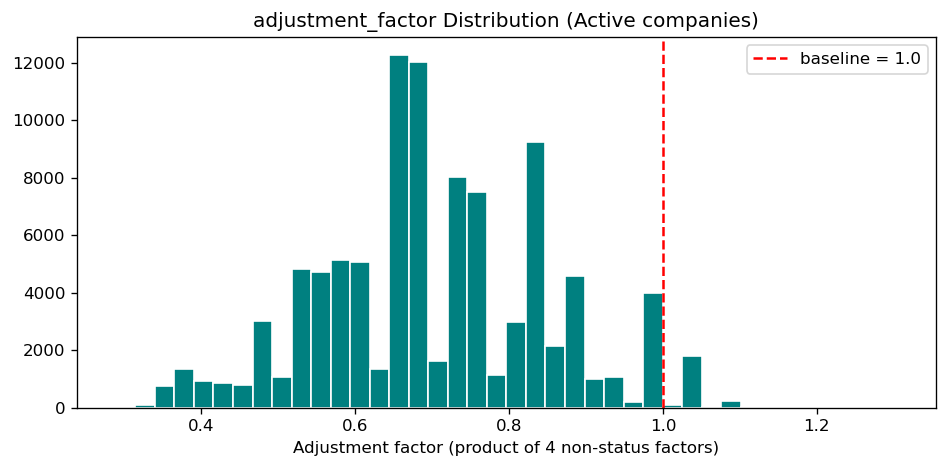

adjustment_factor stats:
count    100000.0000
mean          0.7016
std           0.1458
min           0.2890
25%           0.5985
50%           0.6885
75%           0.8100
max           1.3041


In [8]:
# adjustment_factor 整体分布
if "adjustment_factor" in df.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    active_adj = df[df.get("status_factor", pd.Series(1.0, index=df.index)) == 1.0]["adjustment_factor"]
    ax.hist(active_adj.dropna(), bins=40, color="teal", edgecolor="white")
    ax.axvline(1.0, color="red", linestyle="--", linewidth=1.5, label="baseline = 1.0")
    ax.set_title("adjustment_factor Distribution (Active companies)")
    ax.set_xlabel("Adjustment factor (product of 4 non-status factors)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "04_adjustment_factor.png", bbox_inches="tight")
    plt.show()
    print(f"adjustment_factor stats:")
    print(active_adj.describe().round(4).to_string())

## 5. 按申报类别（AccountCategory）

In [9]:
if "Accounts_AccountCategory" in df.columns:
    cat_summary = df.groupby("Accounts_AccountCategory").agg(
        n          = ("CompanyNumber",         "count"),
        score_mean = ("company_hiring_score",  "mean"),
        score_med  = ("company_hiring_score",  "median"),
        zero_pct   = ("company_hiring_score",
                      lambda x: (x==0).mean()*100),
    ).round(2).sort_values("score_med", ascending=False)
    print(cat_summary.to_string())

                                n  score_mean  score_med  zero_pct
Accounts_AccountCategory                                          
MEDIUM                        183       45.60       45.8       0.0
GROUP                         627       43.03       43.8       0.0
FULL                         1834       42.14       42.4       0.0
SMALL                        1781       38.63       40.4       0.0
UNAUDITED ABRIDGED           4515       38.71       40.1       0.0
AUDIT EXEMPTION SUBSIDIARY    902       35.99       38.1       0.0
MICRO ENTITY                53241       35.92       37.9       0.0
TOTAL EXEMPTION FULL        36917       35.68       37.5       0.0


## 6. 按公司年龄

Score by age band:
                  n  score_mean  score_med  age_factor_mean
age_band                                                   
<2yr           3301       30.08       32.4             0.69
2-3yr          9747       31.08       32.1             0.83
3-7yr (peak)  29367       41.43       44.0             1.15
7-10yr        14901       36.48       39.7             1.00
>10yr         42557       34.10       36.3             0.90


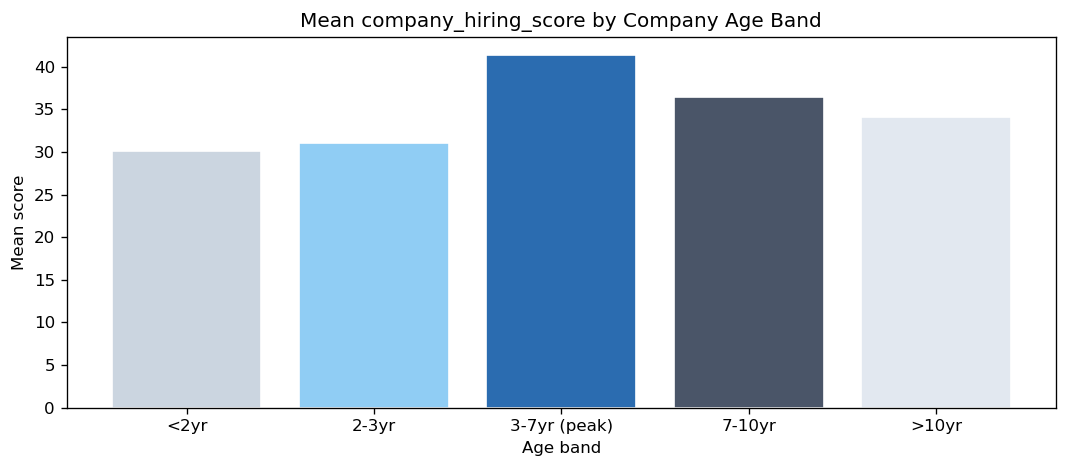

In [10]:
if "company_age_years" in df.columns:
    df["age_band"] = pd.cut(
        df["company_age_years"],
        bins=[0, 2, 3, 7, 10, 100],
        labels=["<2yr", "2-3yr", "3-7yr (peak)", "7-10yr", ">10yr"]
    )

    age_summary = df.groupby("age_band", observed=True).agg(
        n          = ("CompanyNumber",        "count"),
        score_mean = ("company_hiring_score", "mean"),
        score_med  = ("company_hiring_score", "median"),
        age_factor_mean = ("age_factor",      "mean") if "age_factor" in df.columns else ("company_hiring_score", "count"),
    ).round(2)

    print("Score by age band:")
    print(age_summary.to_string())

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(age_summary.index.astype(str), age_summary["score_mean"],
           color=["#CBD5E0","#90CDF4","#2B6CB0","#4A5568","#E2E8F0"],
           edgecolor="white")
    ax.set_title("Mean company_hiring_score by Company Age Band")
    ax.set_xlabel("Age band")
    ax.set_ylabel("Mean score")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "05_by_age.png", bbox_inches="tight")
    plt.show()

## 7. hiring_signal_quality 分析

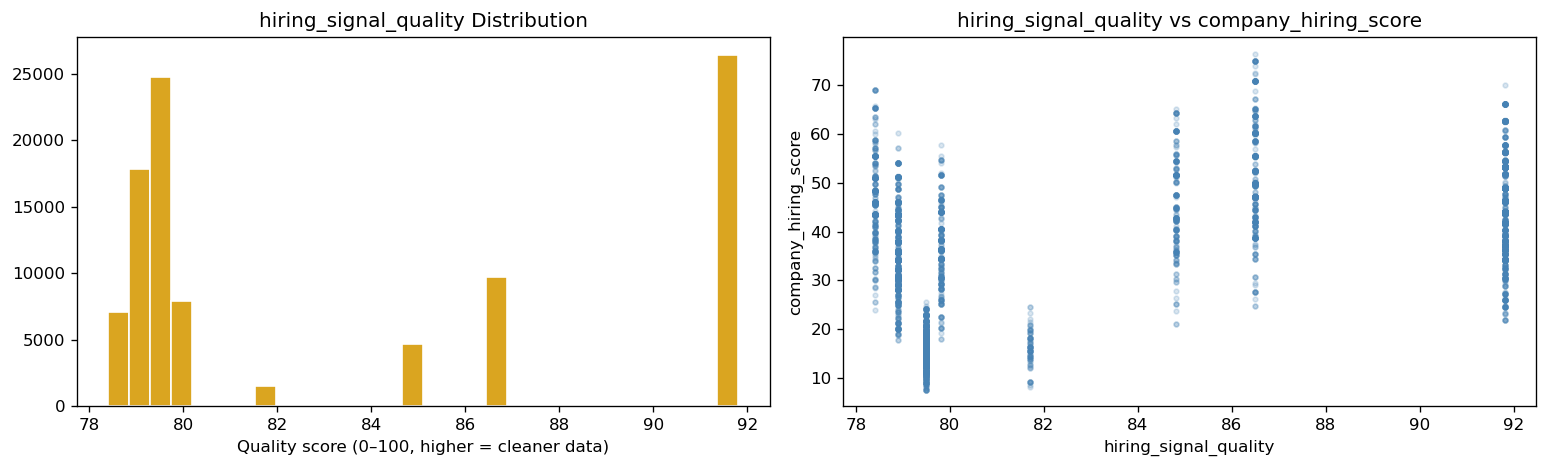


hiring_signal_quality by sector:
                                      mean   min   max
primary_sector                                        
Technology, legal & professional      91.8  91.8  91.8
Fast growth & emerging sector         86.5  86.5  86.5
Public sector, education & charities  84.8  84.8  84.8
Agriculture                           81.7  81.7  81.7
Healthcare                            79.8  79.8  79.8
Real Estate                           79.5  79.5  79.5
Wholesale & Retail                    78.9  78.9  78.9
Manufacturing                         78.4  78.4  78.4


In [11]:
if "hiring_signal_quality" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # 分布
    axes[0].hist(df["hiring_signal_quality"].dropna(), bins=30,
                 color="goldenrod", edgecolor="white")
    axes[0].set_title("hiring_signal_quality Distribution")
    axes[0].set_xlabel("Quality score (0–100, higher = cleaner data)")

    # quality vs hiring score 散点
    sample = df.sample(min(5000, len(df)), random_state=42)
    axes[1].scatter(sample["hiring_signal_quality"],
                    sample["company_hiring_score"],
                    alpha=0.2, s=8, color="steelblue")
    axes[1].set_title("hiring_signal_quality vs company_hiring_score")
    axes[1].set_xlabel("hiring_signal_quality")
    axes[1].set_ylabel("company_hiring_score")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "06_signal_quality.png", bbox_inches="tight")
    plt.show()

    # 按行业的质量
    if "primary_sector" in df.columns:
        print("\nhiring_signal_quality by sector:")
        print(df.groupby("primary_sector")["hiring_signal_quality"]
                .agg(["mean","min","max"]).round(1).sort_values("mean", ascending=False)
                .to_string())

## 8. Top 20 公司预览

In [12]:
preview_cols = ["CompanyNumber", "CompanyName", "primary_sector",
                "company_age_years", "Accounts_AccountCategory",
                "sector_hiring_score", "adjustment_factor",
                "company_hiring_score"]
if "hiring_signal_quality" in df.columns:
    preview_cols.append("hiring_signal_quality")

preview_cols = [c for c in preview_cols if c in df.columns]

top20 = (df[df["company_hiring_score"] > 0]
           .sort_values("company_hiring_score", ascending=False)
           .head(20)[preview_cols]
           .reset_index(drop=True))
print("Top 20 companies by company_hiring_score:")
top20

Top 20 companies by company_hiring_score:


,CompanyNumber,CompanyName,primary_sector,company_age_years,Accounts_AccountCategory,sector_hiring_score,adjustment_factor,company_hiring_score,hiring_signal_quality
0,14303840,BEACON THERAPEUTICS HOLDINGS LIMITED,Fast growth & emerging sector,3.9,GROUP,72.5,1.2075,87.5,86.5
1,12585304,BRIDGESTONE MINING SOLUTIONS TECHNOLOGY LIMITED,Fast growth & emerging sector,6.1,SMALL,72.5,1.1500,83.4,86.5
2,13435794,SIMON-KUCHER ENGINE LTD,Fast growth & emerging sector,5.1,SMALL,72.5,1.1500,83.4,86.5
3,14876627,SENSIO CARE LTD,Fast growth & emerging sector,3.1,SMALL,72.5,1.1500,83.4,86.5
4,11141052,SMARTLY.IO SOLUTIONS LTD,Fast growth & emerging sector,8.5,MEDIUM,72.5,1.1000,79.8,86.5
5,13646174,JOBTEK LTD,Fast growth & emerging sector,4.7,UNAUDITED ABRIDGED,72.5,1.0925,79.2,86.5
6,12091473,CONTENT AND IDEA SOLUTIONS LTD,Fast growth & emerging sector,7.0,UNAUDITED ABRIDGED,72.5,1.0925,79.2,86.5
7,12722351,FLAMBOROUGH BIRD OBSERVATORY TRUST LIMITED,Fast growth & emerging sector,6.0,UNAUDITED ABRIDGED,72.5,1.0925,79.2,86.5
8,13506433,ELLACOTT CONSULTING LTD,Fast growth & emerging sector,5.0,UNAUDITED ABRIDGED,72.5,1.0925,79.2,86.5
9,12296652,LEDGERIQ LTD,Fast growth & emerging sector,6.6,UNAUDITED ABRIDGED,72.5,1.0925,79.2,86.5


## 9. 发现
- 总公司数：100k
- 得分最高的行业：Fast growth & emerging sector 
- 得分最低的行业：Real Estate 
- 3–7年公司的平均得分 vs 全体均值：  41.43  vs  36.18
